In [1]:
import os


os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"

import dataclasses
import json

import numpy as onp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from msmjax.calculators import (
    StaticCellMSMParams,
    static_cell_msm,
    CustomJSONEncoder,
    CustomJSONDecoder,
)
from msmjax.convenience import suggest_msm_params
from msmjax.bspline_interpolation.coefficients import compute_J_zeroplus
from msmjax.benchmark_tools import (
    path_input_structures,
    evaluate_structure_with_lammps_p3m,
)

# Set up

In [2]:
PBC = (False, False, False)
LEVEL_ONE_GRIDSPACING = 1.0
LEVEL_ZERO_CUTOFF = 3.0

In [3]:
structures = onp.load(path_input_structures / "structures_10000.npz")

In [4]:
(n_particles, n_dim) = structures["positions"][0].shape
cell = structures["cells"][0]
pos = structures["positions"][0]
chg = structures["charges"][0]
cell = cell.astype(onp.float64)
pos = pos.astype(onp.float64)
chg = chg.astype(onp.float64)

In [5]:
suggested_params = suggest_msm_params(
    box_lengths=onp.diag(cell),
    pbc=PBC,
    n_particles=n_particles,
    level_one_gridspacing=LEVEL_ONE_GRIDSPACING,
    level_zero_cutoff=LEVEL_ZERO_CUTOFF,
)
suggested_params

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")



{'level_one_gridspacing': [1.0, 1.0, 1.0],
 'level_zero_cutoff': 3.0,
 'p': 4,
 'mu': 14,
 'n_levels': 5}

In [6]:
max_level_split = suggested_params["n_levels"]
if not onp.any(PBC):
    max_level_eval = max_level_split
elif onp.all(PBC):
    max_level_eval = max_level_split - 1
else:
    raise ValueError("Mixed BCs currently not handled.")

convolution_methods = [None] + ["scipy-fft"] * max_level_eval
params_dataclass = StaticCellMSMParams(
    p=suggested_params["p"],
    mu=suggested_params["mu"],
    r_cut_0=suggested_params["level_zero_cutoff"],
    h_1=suggested_params["level_one_gridspacing"],
    max_level_split=max_level_split,
    max_level_eval=max_level_eval,
    cell=cell,
    cell_mode="ortho",
    pbc=PBC,
    supercell_diag=None,
    use_neighborlist=False,
    convolution_methods=convolution_methods,  # TODO: sequence
    grids_defined_on_unitcube=False,  # TODO
)

# Generate reference results

In [7]:
import sys

sys.path.append("/home/florian/PhD/work/code/personal_scripts/")

from matplotlib_snippets.utils import plot_parity_line

from msmjax.core.shortrange import make_eval_pair_pot
from msmjax.benchmark_tools import evaluate_structure_with_lammps_p3m


def calc_energy_ref_nonperiodic(positions, charges):
    n_dim = positions.shape[1]
    compute_pair_term = make_eval_pair_pot(
        kernel_fn=lambda x: 1.0 / x, pbc=(False,) * n_dim
    )
    return compute_pair_term(positions, charges)


def calc_forces_ref_nonperiodic(positions, charges):
    return -jax.grad(calc_energy_ref_nonperiodic, argnums=0)(
        positions, charges
    )


calc_energy_ref_nonperiodic = jax.jit(calc_energy_ref_nonperiodic)
calc_forces_ref_nonperiodic = jax.jit(calc_forces_ref_nonperiodic)

In [8]:
N_PARTICLES_NONPERIODIC = 10000
N_PARTICLES_PERIODIC = 500

onp.load(path_input_structures / f"structures_{N_PARTICLES_NONPERIODIC}.npz")[
    "cells"
][0]

array([[21.544348,  0.      ,  0.      ],
       [ 0.      , 21.544348,  0.      ],
       [ 0.      ,  0.      , 21.544348]], dtype=float32)

# Calculate

In [9]:
(
    calc_energy,
    calc_forces,
    calc_energy_and_forces,
    calc_charge_gradient,
) = static_cell_msm(params_dataclass)

calc_energy = jax.jit(calc_energy)
calc_forces = jax.jit(calc_forces)

In [10]:
# e_msm = calc_energy(pos, chg, neighborlist=jnp.array([1., 2., 3.]))
e_msm = calc_energy(pos, chg)

e_msm

Array(-40.38278237, dtype=float64)

In [11]:
# f_msm = calc_forces(pos, chg, neighborlist=jnp.array([1.0, 2.0, 3.0]))
f_msm = calc_forces(pos, chg)

f_msm

Array([[ 0.73853043, -0.24289055, -0.35225429],
       [-1.23556034, -0.74068227, -0.23327418],
       [-1.12392592, -2.55162579, -0.38015646],
       ...,
       [-0.30609247, -0.78932256, -0.24524063],
       [ 0.91776981,  1.79724765, -0.05913628],
       [ 1.27772065, -0.64229829, -1.76050789]], dtype=float64)

In [12]:
e_ref = calc_energy_ref_nonperiodic(pos, chg)
f_ref = calc_forces_ref_nonperiodic(pos, chg)

e_ref

Array(-37.43308722, dtype=float64)

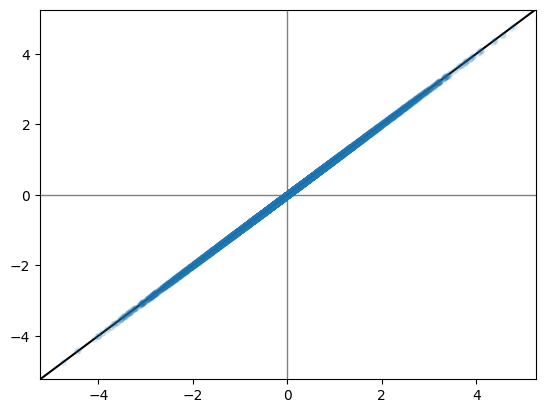

In [13]:
fig, ax = plt.subplots()
ax.scatter(f_ref, f_msm, alpha=0.1, s=15)
ax.axhline(0, color="gray", linewidth=1, zorder=-1)
ax.axvline(0, color="gray", linewidth=1, zorder=-1)
plot_parity_line(ax, color="black", zorder=-1)
plt.show()

# Serialization

In [14]:
# with open("out/params.json", "w") as f:
#     json.dump(
#         dataclasses.asdict(params_dataclass),
#         f,
#         cls=CustomJSONEncoder,
#         indent=2,
#     )

In [15]:
# with open("out/params.json", "r") as f:
#     loaded = json.load(f, cls=CustomJSONDecoder)
# loaded_dataclass = StaticCellMSMParams(**loaded)

In [16]:
def test_params_equal(first: StaticCellMSMParams, second: StaticCellMSMParams):
    if not type(first) is type(second):
        return False
    field_names_first = [field.name for field in dataclasses.fields(first)]
    field_names_second = [field.name for field in dataclasses.fields(second)]
    if not sorted(field_names_first) == sorted(field_names_second):
        return False

    for field_name in field_names_first:
        val_1 = getattr(first, field_name)
        val_2 = getattr(second, field_name)
        if isinstance(val_1, onp.ndarray) and isinstance(val_2, onp.ndarray):
            # TODO: this is not going to work for nested data (like a list of arrays)
            if not onp.array_equal(val_1, val_2):
                return False
        else:
            if val_1 != val_2:
                return False

    return True

In [17]:
# test_params_equal(params_dataclass, loaded_dataclass)

In [18]:
path_jsonfile = "out/params.json"

params_dataclass.save_json(path_jsonfile, indent=2)
assert test_params_equal(
    params_dataclass, StaticCellMSMParams.load_json(path_jsonfile)
)

# Grid setup

In [93]:
from msmjax.bspline_interpolation.coefficients import compute_J_zeroplus
from msmjax.bspline_interpolation.gridops import (
    BSplineInterpolationAxis,
    BSplineInterpolationGrid,
    set_up_grid_axis,
    set_up_grids_all_levels,
    create_restriction_operator_1d,
    create_restriction_operator,
    create_prolongation_operator_1d,
    create_prolongation_operator,
)

In [38]:
P = 4
box_lengths = onp.array([32.0, 21.0, 10.0])
spacings = onp.array([1.0, 1.0, 1.0])
J_zeroplus = compute_J_zeroplus(P)

grids = set_up_grids_all_levels(
    box_lengths=box_lengths,
    level_one_spacings=spacings,
    pbcs=(False, False, False),
    n_levels=7,
    p=P,
    J_zeroplus=J_zeroplus,
)

In [39]:
[None if g is None else g.shape for g in grids]

[None,
 (37, 26, 15),
 (21, 16, 10),
 (13, 11, 8),
 (9, 8, 7),
 (7, 7, 6),
 (6, 6, 6),
 (6, 6, 6)]

In [40]:
def find_n_gridpoints_1d(length, h, p, periodic):
    if p % 2 != 0:
        raise ValueError("p must be even")

    if periodic:
        if not (
            onp.isclose(length % h, 0.0)
            or onp.isclose(length % h, h)
            or onp.isclose(h % length, 0.0)
            or onp.isclose(h % length, length)
        ):
            raise ValueError(
                "Along any periodic axis, the grid spacing must either evenly "
                "divide the box length or be a multiple thereof."
            )
        n_domain = int(onp.ceil(length / h))
        n_total = n_domain
    else:
        # TODO: Is this determination of the number of grid points numerically robust?
        #  OTOH, is it really a concern? (Is +1 actually necessary?)
        n_domain = int(onp.ceil(length / h)) + 1
        n_total = n_domain + p

    return n_total, n_domain

## Cleaner restriction

In [88]:
def make_clean_restrict_1d(
    axis_source_fine: BSplineInterpolationAxis,
    axis_target_coarse: BSplineInterpolationAxis,
):
    # TODO: Change function parameters to (n_points_in, n_points_out, p, periodic)
    #  => directly compute J from p during setup, this should be fine
    p = axis_source_fine.p
    J_zeroplus = axis_source_fine.J_zeroplus
    J = jnp.concatenate((J_zeroplus[::-1][:-1], J_zeroplus))

    n_points_in = axis_source_fine.n_total
    n_points_out = axis_target_coarse.n_total
    # TODO: check n_points_in >= n_points_out?
    periodic = axis_source_fine.periodic

    # TODO: External factory function that creates both `zero_align_idx` and
    #  `to_positional_idx` from `periodic` and `p`

    def zero_align_idx(positional_idx):
        if periodic:
            return positional_idx
        else:
            return positional_idx - p // 2

    def to_positional_idx(zero_aligned_idx):
        if periodic:
            return zero_aligned_idx
        else:
            return zero_aligned_idx + p // 2

    def restrict_1d(in_array_fine: jax.Array) -> jax.Array:
        # TODO: onp backend for these index arrays that could as well be static?
        i = jnp.arange(n_points_out)
        i_aligned = zero_align_idx(i)
        j_aligned = (2 * i_aligned)[:, jnp.newaxis] + jnp.arange(
            -p // 2, p // 2 + 1
        )
        j = to_positional_idx(j_aligned)

        if axis_source_fine.periodic:
            j = j % n_points_in
            selected_source_values = in_array_fine[j]
        else:
            selected_source_values = jnp.where(
                jnp.logical_and(j >= 0, j < n_points_in),
                in_array_fine[j],
                0.0,
            )

        # TODO: check that the output has the same length as axis_target_coarse?
        # TODO: Handle restricting from one point to one point (see branch `one_to_one_edge_cases`)!
        #  Also, does "min number of points -> min number of points" (in nonperiodic case) work correctly?

        return (selected_source_values * J).sum(axis=1)

    return restrict_1d

In [89]:
axis_source_fine = grids[1].axes[0]
axis_target_coarse = grids[2].axes[0]

restrict_1d = jax.jit(
    create_restriction_operator_1d(axis_source_fine, axis_target_coarse)
)
clean_restrict_1d = jax.jit(
    make_clean_restrict_1d(axis_source_fine, axis_target_coarse)
)

n_points_fine = axis_source_fine.n_total
n_points_coarse = axis_target_coarse.n_total

rng = onp.random.default_rng(2479)
in_array = rng.uniform(-1.0, 1.0, size=n_points_fine)
in_array -= in_array.mean()
in_array = jax.device_put(in_array)

In [90]:
assert onp.allclose(
    restrict_1d(in_array), clean_restrict_1d(in_array), atol=1.0e-6
)

%timeit restrict_1d(in_array).block_until_ready()
%timeit clean_restrict_1d(in_array).block_until_ready()

45.4 μs ± 2.78 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
45.1 μs ± 3.5 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Cleaner prolongation

In [95]:
def make_clean_prolongate_1d(
    axis_source_coarse: BSplineInterpolationAxis,
    axis_target_fine: BSplineInterpolationAxis,
):
    # TODO: Change function parameters to (n_points_in, n_points_out, p, periodic)
    #  => directly compute J from p during setup, this should be fine
    p = axis_source_coarse.p
    J_zeroplus = axis_source_coarse.J_zeroplus
    J = jnp.concatenate((J_zeroplus[::-1][:-1], J_zeroplus))

    n_points_in = axis_source_coarse.n_total
    n_points_out = axis_target_fine.n_total
    # TODO: check n_points_in >= n_points_out?
    periodic = axis_source_coarse.periodic

    # TODO: External factory function that creates both `zero_align_idx` and
    #  `to_positional_idx` from `periodic` and `p`

    def zero_align_idx(positional_idx):
        if periodic:
            return positional_idx
        else:
            return positional_idx - p // 2

    def to_positional_idx(zero_aligned_idx):
        if periodic:
            return zero_aligned_idx
        else:
            return zero_aligned_idx + p // 2

    # TODO: get_neighbor_inds_on_sourcegrid_even, get_neighbor_inds_on_sourcegrid_odd?

    start_even = int(onp.ceil(onp.round(-p / 4, decimals=1)))
    end_even = int(onp.floor(onp.round(p / 4, decimals=1)))
    start_odd = int(onp.ceil(onp.round(0.5 - p / 4, decimals=1)))
    end_odd = int(onp.floor(onp.round(0.5 + p / 4, decimals=1)))
    dists_to_neighbors_even = jnp.arange(start_even, end_even + 1)
    dists_to_neighbors_odd = jnp.arange(start_odd, end_odd + 1)

    inds_into_J_even = -2 * dists_to_neighbors_even
    inds_into_J_odd = 1 - 2 * dists_to_neighbors_odd

    if periodic:
        slice_even = slice(0, None, 2)
        slice_odd = slice(1, None, 2)
    else:
        slice_even = slice((p // 2) % 2, None, 2)
        slice_odd = slice(1 - (p // 2) % 2, None, 2)

    def prolongate_1d(in_array_coarse: jax.Array) -> jax.Array:
        i = jnp.arange(n_points_out)

        i_even = i[slice_even]
        i_even_aligned = zero_align_idx(i_even)
        j_even_aligned = i_even_aligned // 2 + dists_to_neighbors_even
        j_even = to_positional_idx(j_even_aligned)

        i_odd = i[slice_odd]
        i_odd_aligned = zero_align_idx(i_odd)
        j_odd_aligned = i_odd_aligned // 2 + dists_to_neighbors_odd
        j_odd = to_positional_idx(j_odd_aligned)

        result = jnp.zeros(n_points_out)
        result = result.at[i_even].add(
            (
                in_array_coarse[j_even] * J_zeroplus[jnp.abs(inds_into_J_even)]
            ).sum(axis=1)
        )
        result = result.at[i_odd].add(
            (
                in_array_coarse[j_odd] * J_zeroplus[jnp.abs(inds_into_J_odd)]
            ).sum(axis=1)
        )

        return result

    return prolongate_1d

In [96]:
axis_source_coarse = grids[2].axes[0]
axis_target_fine = grids[1].axes[0]

prolongate_1d = jax.jit(
    create_prolongation_operator_1d(axis_source_coarse, axis_target_fine)
)
clean_prolongate_1d = jax.jit(
    make_clean_prolongate_1d(axis_source_coarse, axis_target_fine)
)

n_points_coarse = axis_source_coarse.n_total
n_points_fine = axis_target_fine.n_total

rng = onp.random.default_rng(2479)
gridpotential_coarse = rng.uniform(-1.0, 1.0, size=n_points_coarse)
gridpotential_coarse -= gridpotential_coarse.mean()
gridpotential_coarse = jax.device_put(gridpotential_coarse)

In [98]:
assert onp.allclose(
    restrict_1d(gridpotential_coarse),
    clean_restrict_1d(gridpotential_coarse),
    atol=1.0e-6,
)

%timeit restrict_1d(gridpotential_coarse).block_until_ready()
%timeit clean_restrict_1d(gridpotential_coarse).block_until_ready()

42.5 μs ± 4.28 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
42 μs ± 3.85 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
